<a href="https://colab.research.google.com/github/ryonahh/ML_MiniProject_53/blob/main/Olympic_Medal_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olympic Medal Prediction Using Machine Learning

## Problem Statement
Can Olympic medal performance be predicted more reliably by incorporating
historical performance trends, socioeconomic indicators, and athlete
participation features while evaluating generalization on future Olympic Games?

## Objectives

1. Analyze historical Olympic medal and athlete data.
2. Integrate socioeconomic indicators from the World Bank.
3. Engineer temporal and performance-efficiency features.
4. Compare multiple machine learning models.
5. Evaluate performance using future Olympic Games as unseen data.


In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

In [41]:
import pandas as pd
import numpy as np

athletes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/athlete_events.csv')
noc = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/noc_regions.csv')
wdi = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WDICSV.csv')

In [42]:
print("Athletes:", athletes.shape)
print("NOC:", noc.shape)
print("WDI:", wdi.shape)

Athletes: (271116, 15)
NOC: (230, 3)
WDI: (396970, 70)


In [43]:
wdi['Indicator Name'].unique()


array(['Access to clean fuels and technologies for cooking (% of population)',
       'Access to clean fuels and technologies for cooking, rural (% of rural population)',
       'Access to clean fuels and technologies for cooking, urban (% of urban population)',
       ...,
       'Women who were first married by age 18 (% of women ages 20-24)',
       "Women's share of population ages 15+ living with HIV (%)",
       'Young people (ages 15-24) newly infected with HIV'], dtype=object)

In [44]:
# Check whether our required World Bank indicators exist

required_indicators = {
    'GDP': 'NY.GDP.MKTP.CD',
    'GDP_per_Capita': 'NY.GDP.PCAP.CD',
    'Population': 'SP.POP.TOTL',
    'GDP_Growth': 'NY.GDP.MKTP.KD.ZG',
    'Population_Growth': 'SP.POP.GROW'
}

for name, code in required_indicators.items():
    matches = wdi[wdi['Indicator Code'] == code]['Indicator Name'].unique()

    if len(matches) > 0:
        print(f"✓ {name}: {code}")
        print(f"  → {matches[0]}")
    else:
        print(f"✗ {name}: {code} NOT FOUND")

✓ GDP: NY.GDP.MKTP.CD
  → GDP (current US$)
✓ GDP_per_Capita: NY.GDP.PCAP.CD
  → GDP per capita (current US$)
✓ Population: SP.POP.TOTL
  → Population, total
✓ GDP_Growth: NY.GDP.MKTP.KD.ZG
  → GDP growth (annual %)
✓ Population_Growth: SP.POP.GROW
  → Population growth (annual %)


In [45]:
# Shows the exact rows for our selected indicators

wdi[
    wdi['Indicator Code'].isin(required_indicators.values())
][['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']].drop_duplicates().head(20)

,Country Name,Country Code,Indicator Name,Indicator Code
511,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD
514,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG
518,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD
1114,Africa Eastern and Southern,AFE,Population growth (annual %),SP.POP.GROW
1125,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL
2009,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD
2012,Africa Western and Central,AFW,GDP growth (annual %),NY.GDP.MKTP.KD.ZG
2016,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD
2612,Africa Western and Central,AFW,Population growth (annual %),SP.POP.GROW
2623,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL


In [46]:
#extracting world bank indicators
required_indicators = {
    'GDP': 'NY.GDP.MKTP.CD',
    'GDP_per_Capita': 'NY.GDP.PCAP.CD',
    'Population': 'SP.POP.TOTL',
    'GDP_Growth': 'NY.GDP.MKTP.KD.ZG',
    'Population_Growth': 'SP.POP.GROW'
}

for name, code in required_indicators.items():
    matches = wdi[wdi['Indicator Code'] == code]['Indicator Name'].unique()

    if len(matches) > 0:
        print(f"✓ {name}: {code}")
        print(f"  {matches[0]}")
    else:
        print(f"✗ {name}: {code} NOT FOUND")

✓ GDP: NY.GDP.MKTP.CD
  GDP (current US$)
✓ GDP_per_Capita: NY.GDP.PCAP.CD
  GDP per capita (current US$)
✓ Population: SP.POP.TOTL
  Population, total
✓ GDP_Growth: NY.GDP.MKTP.KD.ZG
  GDP growth (annual %)
✓ Population_Growth: SP.POP.GROW
  Population growth (annual %)


In [47]:
selected_codes = list(required_indicators.values())

wdi_selected = wdi[
    wdi['Indicator Code'].isin(selected_codes)
].copy()

print("Rows:", len(wdi_selected))
wdi_selected.head()

Rows: 1325


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
511,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.420573e+10,2.495893e+10,2.707328e+10,3.176919e+10,3.027960e+10,3.380623e+10,...,8.326614e+11,9.792406e+11,1.021972e+12,1.019354e+12,9.385461e+11,1.113060e+12,1.226461e+12,1.179122e+12,1.252564e+12,1.358694e+12
514,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,4.186045e-01,7.937089e+00,5.624317e+00,4.650349e+00,5.138153e+00,...,2.292501e+00,2.678863e+00,2.706207e+00,1.935593e+00,-2.930764e+00,4.452643e+00,3.668029e+00,1.941382e+00,2.787931e+00,3.743016e+00
518,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1.860895e+02,1.869094e+02,1.973679e+02,2.254005e+02,2.089631e+02,2.268365e+02,...,1.335743e+03,1.529923e+03,1.553618e+03,1.508032e+03,1.351503e+03,1.560895e+03,1.675903e+03,1.571133e+03,1.628227e+03,1.722386e+03
1114,Africa Eastern and Southern,AFE,Population growth (annual %),SP.POP.GROW,NaN,2.624624e+00,2.687009e+00,2.714042e+00,2.769856e+00,2.809882e+00,...,2.640743e+00,2.642067e+00,2.734263e+00,2.721681e+00,2.699516e+00,2.649439e+00,2.592754e+00,2.519167e+00,2.472801e+00,2.511278e+00
1125,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1.300757e+08,1.335349e+08,1.371717e+08,1.409455e+08,1.449041e+08,1.490335e+08,...,6.233694e+08,6.400587e+08,6.578011e+08,6.759502e+08,6.944461e+08,7.130909e+08,7.318214e+08,7.504914e+08,7.692809e+08,7.888443e+08


In [48]:
year_columns = [
    col for col in wdi_selected.columns
    if str(col).isdigit()
]

wdi_long = wdi_selected.melt(
    id_vars=[
        'Country Name',
        'Country Code',
        'Indicator Name',
        'Indicator Code'
    ],
    value_vars=year_columns,
    var_name='Year',
    value_name='Value'
)

wdi_long['Year'] = wdi_long['Year'].astype(int)

wdi_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
0,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,1960,2.420573e+10
1,Africa Eastern and Southern,AFE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,1960,NaN
2,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,1.860895e+02
3,Africa Eastern and Southern,AFE,Population growth (annual %),SP.POP.GROW,1960,NaN
4,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,1960,1.300757e+08


In [49]:
wdi_final = wdi_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Indicator Code',
    values='Value',
    aggfunc='first'
).reset_index()

In [50]:
wdi_final = wdi_final.rename(columns={
    'NY.GDP.MKTP.CD': 'GDP',
    'NY.GDP.PCAP.CD': 'GDP_per_Capita',
    'SP.POP.TOTL': 'Population',
    'NY.GDP.MKTP.KD.ZG': 'GDP_Growth',
    'SP.POP.GROW': 'Population_Growth'
})

In [51]:
wdi_final.head()


Indicator Code,Country Name,Country Code,Year,GDP,GDP_Growth,GDP_per_Capita,Population_Growth,Population
0,Afghanistan,AFG,1960,NaN,NaN,NaN,NaN,9035043.0
1,Afghanistan,AFG,1961,NaN,NaN,NaN,1.962239,9214083.0
2,Afghanistan,AFG,1962,NaN,NaN,NaN,2.044523,9404406.0
3,Afghanistan,AFG,1963,NaN,NaN,NaN,2.105208,9604487.0
4,Afghanistan,AFG,1964,NaN,NaN,NaN,2.161195,9814318.0


In [52]:
wdi_final.columns

Index(['Country Name', 'Country Code', 'Year', 'GDP', 'GDP_Growth',
       'GDP_per_Capita', 'Population_Growth', 'Population'],
      dtype='object', name='Indicator Code')

In [53]:
sorted(athletes['Year'].unique())

[np.int64(1896),
 np.int64(1900),
 np.int64(1904),
 np.int64(1906),
 np.int64(1908),
 np.int64(1912),
 np.int64(1920),
 np.int64(1924),
 np.int64(1928),
 np.int64(1932),
 np.int64(1936),
 np.int64(1948),
 np.int64(1952),
 np.int64(1956),
 np.int64(1960),
 np.int64(1964),
 np.int64(1968),
 np.int64(1972),
 np.int64(1976),
 np.int64(1980),
 np.int64(1984),
 np.int64(1988),
 np.int64(1992),
 np.int64(1994),
 np.int64(1996),
 np.int64(1998),
 np.int64(2000),
 np.int64(2002),
 np.int64(2004),
 np.int64(2006),
 np.int64(2008),
 np.int64(2010),
 np.int64(2012),
 np.int64(2014),
 np.int64(2016)]

In [54]:
olympic_years = sorted(athletes['Year'].unique())

wdi_olympic = wdi_final[
    wdi_final['Year'].isin(olympic_years)
].copy()

print(wdi_olympic.shape)

(5536, 8)


In [55]:
athletes.columns.tolist()

['ID',
 'Name',
 'Sex',
 'Age',
 'Height',
 'Weight',
 'Team',
 'NOC',
 'Games',
 'Year',
 'Season',
 'City',
 'Sport',
 'Event',
 'Medal']

In [56]:
noc.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [57]:
noc.columns.tolist()

['NOC', 'region', 'notes']

In [58]:
athletes = athletes.merge(
    noc[['NOC', 'region']],
    on='NOC',
    how='left'
)

In [59]:
athletes = athletes.rename(
    columns={'region': 'Country'}
)

In [60]:
athletes[['NOC', 'Country']].drop_duplicates().head(20)

,NOC,Country
0,CHN,China
2,DEN,Denmark
4,NED,Netherlands
10,USA,USA
28,FIN,Finland
59,NOR,Norway
80,ROU,Romania
94,EST,Estonia
98,FRA,France
134,MAR,Morocco


In [61]:
athletes['Gold'] = (athletes['Medal'] == 'Gold').astype(int)
athletes['Silver'] = (athletes['Medal'] == 'Silver').astype(int)
athletes['Bronze'] = (athletes['Medal'] == 'Bronze').astype(int)

In [62]:
athletes[['Medal', 'Gold', 'Silver', 'Bronze']].head(20)

,Medal,Gold,Silver,Bronze
0,NaN,0,0,0
1,NaN,0,0,0
2,NaN,0,0,0
3,Gold,1,0,0
4,NaN,0,0,0
5,NaN,0,0,0
6,NaN,0,0,0
7,NaN,0,0,0
8,NaN,0,0,0
9,NaN,0,0,0


In [63]:
olympic_country_year = athletes.groupby(
    ['Country', 'Year']
).agg(
    Athletes=('Name', 'nunique'),
    Sports=('Sport', 'nunique'),
    Events=('Event', 'nunique'),
    Gold=('Gold', 'sum'),
    Silver=('Silver', 'sum'),
    Bronze=('Bronze', 'sum')
).reset_index()

In [64]:
olympic_country_year['Total_Medals'] = (
    olympic_country_year['Gold'] +
    olympic_country_year['Silver'] +
    olympic_country_year['Bronze']
)

In [65]:
olympic_country_year.head(20)

,Country,Year,Athletes,Sports,Events,Gold,Silver,Bronze,Total_Medals
0,Afghanistan,1936,15,2,4,0,0,0,0
1,Afghanistan,1948,25,2,2,0,0,0,0
2,Afghanistan,1956,12,1,1,0,0,0,0
3,Afghanistan,1960,12,2,13,0,0,0,0
4,Afghanistan,1964,8,1,8,0,0,0,0
5,Afghanistan,1968,5,1,5,0,0,0,0
6,Afghanistan,1972,8,1,8,0,0,0,0
7,Afghanistan,1980,11,2,11,0,0,0,0
8,Afghanistan,1988,5,1,5,0,0,0,0
9,Afghanistan,1996,2,1,2,0,0,0,0


In [66]:
print(olympic_country_year.shape)

(3258, 9)


In [67]:
athletes['Season'].value_counts()

,count
Season,
Summer,222552
Winter,48564


In [68]:
athletes_summer = athletes[
    athletes['Season'] == 'Summer'
].copy()

In [69]:
olympic_country_year = athletes_summer.groupby(
    ['Country', 'Year']
).agg(
    Athletes=('Name', 'nunique'),
    Sports=('Sport', 'nunique'),
    Events=('Event', 'nunique'),
    Gold=('Gold', 'sum'),
    Silver=('Silver', 'sum'),
    Bronze=('Bronze', 'sum')
).reset_index()

olympic_country_year['Total_Medals'] = (
    olympic_country_year['Gold'] +
    olympic_country_year['Silver'] +
    olympic_country_year['Bronze']
)

In [70]:
olympic_country_year.head(20)

,Country,Year,Athletes,Sports,Events,Gold,Silver,Bronze,Total_Medals
0,Afghanistan,1936,15,2,4,0,0,0,0
1,Afghanistan,1948,25,2,2,0,0,0,0
2,Afghanistan,1956,12,1,1,0,0,0,0
3,Afghanistan,1960,12,2,13,0,0,0,0
4,Afghanistan,1964,8,1,8,0,0,0,0
5,Afghanistan,1968,5,1,5,0,0,0,0
6,Afghanistan,1972,8,1,8,0,0,0,0
7,Afghanistan,1980,11,2,11,0,0,0,0
8,Afghanistan,1988,5,1,5,0,0,0,0
9,Afghanistan,1996,2,1,2,0,0,0,0


In [71]:
olympic_country_year.describe()

,Year,Athletes,Sports,Events,Gold,Silver,Bronze,Total_Medals
count,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000,2769.000000
mean,1981.200433,57.238353,7.858794,35.063561,4.137956,4.050560,4.118815,12.307331
std,29.607511,94.253280,6.942315,46.652428,14.736208,11.778712,11.264232,35.279496
min,1896.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1964.000000,6.000000,3.000000,6.000000,0.000000,0.000000,0.000000,0.000000
50%,1988.000000,18.000000,5.000000,15.000000,0.000000,0.000000,0.000000,0.000000
75%,2004.000000,63.000000,12.000000,46.000000,1.000000,2.000000,2.000000,6.000000
max,2016.000000,735.000000,34.000000,270.000000,187.000000,141.000000,126.000000,442.000000


In [72]:
olympic_country_year['Year'].unique()

array([1936, 1948, 1956, 1960, 1964, 1968, 1972, 1980, 1988, 1996, 2004,
       2008, 2012, 2016, 1992, 2000, 1984, 1976, 1900, 1908, 1920, 1924,
       1928, 1932, 1952, 1896, 1904, 1906, 1912])

In [73]:
print(olympic_country_year.shape)
print(olympic_country_year.head())
print(olympic_country_year.tail())

(2769, 9)
       Country  Year  Athletes  Sports  Events  Gold  Silver  Bronze  \
0  Afghanistan  1936        15       2       4     0       0       0   
1  Afghanistan  1948        25       2       2     0       0       0   
2  Afghanistan  1956        12       1       1     0       0       0   
3  Afghanistan  1960        12       2      13     0       0       0   
4  Afghanistan  1964         8       1       8     0       0       0   

   Total_Medals  
0             0  
1             0  
2             0  
3             0  
4             0  
       Country  Year  Athletes  Sports  Events  Gold  Silver  Bronze  \
2764  Zimbabwe  2000        16       5      19     0       0       0   
2765  Zimbabwe  2004        12       4      11     1       1       1   
2766  Zimbabwe  2008        13       6      15     1       3       0   
2767  Zimbabwe  2012         7       4       8     0       0       0   
2768  Zimbabwe  2016        30       7      13     0       0       0   

      Total_Meda

In [74]:
print(wdi_final.columns.tolist())

['Country Name', 'Country Code', 'Year', 'GDP', 'GDP_Growth', 'GDP_per_Capita', 'Population_Growth', 'Population']


In [75]:
olympic_country_year = olympic_country_year.sort_values(
    ['Country', 'Year']
).reset_index(drop=True)

In [76]:
olympic_country_year['Previous_Medals'] = (
    olympic_country_year
    .groupby('Country')['Total_Medals']
    .shift(1)
)

In [77]:
olympic_country_year['Previous_Gold'] = (
    olympic_country_year
    .groupby('Country')['Gold']
    .shift(1)
)

In [78]:
olympic_country_year['Medal_Growth'] = (
    olympic_country_year
    .groupby('Country')['Total_Medals']
    .pct_change()
)

In [79]:
olympic_country_year['Athlete_Growth'] = (
    olympic_country_year
    .groupby('Country')['Athletes']
    .pct_change()
)

In [80]:
olympic_country_year['Rolling_3_Medal_Avg'] = (
    olympic_country_year
    .groupby('Country')['Total_Medals']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

In [82]:
olympic_country_year['Previous_Athletes'] = (
    olympic_country_year
    .groupby('Country')['Athletes']
    .shift(1)
)

In [83]:
olympic_country_year['Medal_Efficiency'] = (
    olympic_country_year['Previous_Medals'] /
    olympic_country_year['Previous_Athletes']
)

In [84]:
olympic_country_year.head(20)

,Country,Year,Athletes,Sports,Events,Gold,Silver,Bronze,Total_Medals,Previous_Medals,Previous_Gold,Medal_Growth,Athlete_Growth,Rolling_3_Medal_Avg,Previous_Athletes,Medal_Efficiency
0,Afghanistan,1936,15,2,4,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1948,25,2,2,0,0,0,0,0.0,0.0,NaN,0.666667,0.000000,15.0,0.000000
2,Afghanistan,1956,12,1,1,0,0,0,0,0.0,0.0,NaN,-0.520000,0.000000,25.0,0.000000
3,Afghanistan,1960,12,2,13,0,0,0,0,0.0,0.0,NaN,0.000000,0.000000,12.0,0.000000
4,Afghanistan,1964,8,1,8,0,0,0,0,0.0,0.0,NaN,-0.333333,0.000000,12.0,0.000000
5,Afghanistan,1968,5,1,5,0,0,0,0,0.0,0.0,NaN,-0.375000,0.000000,8.0,0.000000
6,Afghanistan,1972,8,1,8,0,0,0,0,0.0,0.0,NaN,0.600000,0.000000,5.0,0.000000
7,Afghanistan,1980,11,2,11,0,0,0,0,0.0,0.0,NaN,0.375000,0.000000,8.0,0.000000
8,Afghanistan,1988,5,1,5,0,0,0,0,0.0,0.0,NaN,-0.545455,0.000000,11.0,0.000000
9,Afghanistan,1996,2,1,2,0,0,0,0,0.0,0.0,NaN,-0.600000,0.000000,5.0,0.000000


In [85]:
olympic_country_year[
    [
        'Country',
        'Year',
        'Total_Medals',
        'Previous_Medals',
        'Previous_Gold',
        'Medal_Growth',
        'Athlete_Growth',
        'Rolling_3_Medal_Avg',
        'Medal_Efficiency'
    ]
].head(30)

,Country,Year,Total_Medals,Previous_Medals,Previous_Gold,Medal_Growth,Athlete_Growth,Rolling_3_Medal_Avg,Medal_Efficiency
0,Afghanistan,1936,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1948,0,0.0,0.0,NaN,0.666667,0.000000,0.000000
2,Afghanistan,1956,0,0.0,0.0,NaN,-0.520000,0.000000,0.000000
3,Afghanistan,1960,0,0.0,0.0,NaN,0.000000,0.000000,0.000000
4,Afghanistan,1964,0,0.0,0.0,NaN,-0.333333,0.000000,0.000000
5,Afghanistan,1968,0,0.0,0.0,NaN,-0.375000,0.000000,0.000000
6,Afghanistan,1972,0,0.0,0.0,NaN,0.600000,0.000000,0.000000
7,Afghanistan,1980,0,0.0,0.0,NaN,0.375000,0.000000,0.000000
8,Afghanistan,1988,0,0.0,0.0,NaN,-0.545455,0.000000,0.000000
9,Afghanistan,1996,0,0.0,0.0,NaN,-0.600000,0.000000,0.000000


In [86]:
olympic_country_year[
    [
        'Country',
        'Year',
        'Total_Medals',
        'Previous_Medals',
        'Previous_Gold',
        'Medal_Growth',
        'Athlete_Growth',
        'Rolling_3_Medal_Avg',
        'Medal_Efficiency'
    ]
].head(30)

,Country,Year,Total_Medals,Previous_Medals,Previous_Gold,Medal_Growth,Athlete_Growth,Rolling_3_Medal_Avg,Medal_Efficiency
0,Afghanistan,1936,0,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1948,0,0.0,0.0,NaN,0.666667,0.000000,0.000000
2,Afghanistan,1956,0,0.0,0.0,NaN,-0.520000,0.000000,0.000000
3,Afghanistan,1960,0,0.0,0.0,NaN,0.000000,0.000000,0.000000
4,Afghanistan,1964,0,0.0,0.0,NaN,-0.333333,0.000000,0.000000
5,Afghanistan,1968,0,0.0,0.0,NaN,-0.375000,0.000000,0.000000
6,Afghanistan,1972,0,0.0,0.0,NaN,0.600000,0.000000,0.000000
7,Afghanistan,1980,0,0.0,0.0,NaN,0.375000,0.000000,0.000000
8,Afghanistan,1988,0,0.0,0.0,NaN,-0.545455,0.000000,0.000000
9,Afghanistan,1996,0,0.0,0.0,NaN,-0.600000,0.000000,0.000000


In [87]:
olympic_country_year[
    [
        'Previous_Medals',
        'Previous_Gold',
        'Medal_Growth',
        'Athlete_Growth',
        'Rolling_3_Medal_Avg',
        'Medal_Efficiency'
    ]
].isna().sum()

,0
Previous_Medals,205
Previous_Gold,205
Medal_Growth,1384
Athlete_Growth,205
Rolling_3_Medal_Avg,205
Medal_Efficiency,205


## 7. Temporal Feature Engineering

To predict Olympic medal performance for a given Olympic year,
we construct features using only information available from
previous Olympic Games.

The engineered features include:
- Previous medal count
- Previous gold medal count
- Medal growth
- Athlete participation growth
- Three-Olympics rolling medal average
- Medal efficiency

These features are designed to capture historical performance,
participation trends, and Olympic performance momentum while
avoiding temporal data leakage.

In [88]:
olympic_country_year[
    [
        'Previous_Medals',
        'Previous_Gold',
        'Medal_Growth',
        'Athlete_Growth',
        'Rolling_3_Medal_Avg',
        'Medal_Efficiency'
    ]
].isna().sum()

,0
Previous_Medals,205
Previous_Gold,205
Medal_Growth,1384
Athlete_Growth,205
Rolling_3_Medal_Avg,205
Medal_Efficiency,205


In [89]:
olympic_country_year.shape

(2769, 16)

In [90]:
olympic_country_year[
    olympic_country_year['Previous_Medals'].isna()
][['Country', 'Year']].head(20)

,Country,Year
0,Afghanistan,1936
14,Albania,1972
22,Algeria,1964
35,American Samoa,1988
43,Andorra,1976
54,Angola,1980
63,Antigua,1976
73,Argentina,1900
97,Armenia,1996
103,Aruba,1988


In [91]:
model_data = olympic_country_year.dropna(
    subset=['Previous_Medals']
).copy()

In [92]:
print("Original rows:", len(olympic_country_year))
print("ML rows:", len(model_data))

Original rows: 2769
ML rows: 2564


In [93]:
model_data.isna().sum()

,0
Country,0
Year,0
Athletes,0
Sports,0
Events,0
Gold,0
Silver,0
Bronze,0
Total_Medals,0
Previous_Medals,0


In [94]:
model_data.isna().sum()

,0
Country,0
Year,0
Athletes,0
Sports,0
Events,0
Gold,0
Silver,0
Bronze,0
Total_Medals,0
Previous_Medals,0


In [95]:
features = [
    'Previous_Medals',
    'Previous_Gold',
    'Medal_Growth',
    'Athlete_Growth',
    'Rolling_3_Medal_Avg',
    'Medal_Efficiency',
    'Athletes',
    'Sports',
    'Events'
]

target = 'Total_Medals'

X = model_data[features].copy()
y = model_data[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2564, 9)
y shape: (2564,)


In [96]:
growth_features = [
    'Medal_Growth',
    'Athlete_Growth',
    'Rolling_3_Medal_Avg',
    'Medal_Efficiency'
]

X[growth_features] = X[growth_features].fillna(0)

In [97]:
print(X.isna().sum())

Previous_Medals        0
Previous_Gold          0
Medal_Growth           0
Athlete_Growth         0
Rolling_3_Medal_Avg    0
Medal_Efficiency       0
Athletes               0
Sports                 0
Events                 0
dtype: int64


In [98]:
sorted(model_data['Year'].unique())

[np.int64(1900),
 np.int64(1904),
 np.int64(1906),
 np.int64(1908),
 np.int64(1912),
 np.int64(1920),
 np.int64(1924),
 np.int64(1928),
 np.int64(1932),
 np.int64(1936),
 np.int64(1948),
 np.int64(1952),
 np.int64(1956),
 np.int64(1960),
 np.int64(1964),
 np.int64(1968),
 np.int64(1972),
 np.int64(1976),
 np.int64(1980),
 np.int64(1984),
 np.int64(1988),
 np.int64(1992),
 np.int64(1996),
 np.int64(2000),
 np.int64(2004),
 np.int64(2008),
 np.int64(2012),
 np.int64(2016)]

In [107]:
train_data = model_data[
    model_data['Year'] <= 2008
].copy()

val_data = model_data[
    model_data['Year'].isin([2012])
].copy()

test_data = model_data[
    model_data['Year'].isin([2016])
].copy()

print("Training:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Training: (2161, 16)
Validation: (202, 16)
Test: (201, 16)


In [100]:
X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_val = val_data[features].copy()
y_val = val_data[target].copy()

X_test = test_data[features].copy()
y_test = test_data[target].copy()

In [101]:
for df in [X_train, X_val, X_test]:
    df[growth_features] = df[growth_features].fillna(0)

In [102]:
print("Training years:")
print(sorted(train_data['Year'].unique()))

print("\nValidation years:")
print(sorted(val_data['Year'].unique()))

print("\nTest years:")
print(sorted(test_data['Year'].unique()))

Training years:
[np.int64(1900), np.int64(1904), np.int64(1906), np.int64(1908), np.int64(1912), np.int64(1920), np.int64(1924), np.int64(1928), np.int64(1932), np.int64(1936), np.int64(1948), np.int64(1952), np.int64(1956), np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008)]

Validation years:
[np.int64(2012), np.int64(2016)]

Test years:
[]


In [103]:
baseline_features = [
    'Previous_Medals',
    'Previous_Gold'
]

X_train_base = X_train[baseline_features]
X_val_base = X_val[baseline_features]
X_test_base = X_test[baseline_features]

In [104]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

baseline_model.fit(
    X_train_base,
    y_train
)

RandomForestRegressor(max_depth=8, min_samples_leaf=3, n_estimators=300,
                      random_state=42)

In [109]:
baseline_pred = baseline_model.predict(X_test_base)

ValueError: Found array with 0 sample(s) (shape=(0, 2)) while a minimum of 1 is required by RandomForestRegressor.

In [145]:
train_data = model_data[
    model_data['Year'] <= 2008
].copy()

val_data = model_data[
    model_data['Year'].isin([2012])
].copy()

test_data = model_data[
    model_data['Year'].isin([2016])
].copy()

print("Training:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Training: (2161, 16)
Validation: (202, 16)
Test: (201, 16)


In [146]:
X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_val = val_data[features].copy()
y_val = val_data[target].copy()

X_test = test_data[features].copy()
y_test = test_data[target].copy()

In [147]:
for df in [X_train, X_val, X_test]:
    df[growth_features] = df[growth_features].fillna(0)

In [148]:
baseline_features = [
    'Previous_Medals',
    'Previous_Gold'
]

X_train_base = X_train[baseline_features]
X_val_base = X_val[baseline_features]
X_test_base = X_test[baseline_features]

In [149]:
baseline_pred = baseline_model.predict(X_test_base)

In [115]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("BASELINE RESULTS")
print("----------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("R²  :", baseline_r2)

BASELINE RESULTS
----------------
MAE : 3.716200378846793
RMSE: 8.885900592388369
R²  : 0.9083917167733099


## 8. Leakage-Free Temporal Feature Engineering

All predictive features must be available before the target Olympic Games.
Therefore, current-Olympics participation and performance values are shifted
to use information from previous Olympic Games only.

In [116]:
# Previous participation
olympic_country_year['Previous_Athletes'] = (
    olympic_country_year
    .groupby('Country')['Athletes']
    .shift(1)
)

olympic_country_year['Previous_Sports'] = (
    olympic_country_year
    .groupby('Country')['Sports']
    .shift(1)
)

olympic_country_year['Previous_Events'] = (
    olympic_country_year
    .groupby('Country')['Events']
    .shift(1)
)

In [117]:
olympic_country_year['Historical_Medal_Growth'] = (
    olympic_country_year
    .groupby('Country')['Total_Medals']
    .pct_change()
    .groupby(olympic_country_year['Country'])
    .shift(1)
)

In [118]:
olympic_country_year['Historical_Athlete_Growth'] = (
    olympic_country_year
    .groupby('Country')['Athletes']
    .pct_change()
    .groupby(olympic_country_year['Country'])
    .shift(1)
)

In [119]:
proposed_features = [
    'Previous_Medals',
    'Previous_Gold',
    'Historical_Medal_Growth',
    'Historical_Athlete_Growth',
    'Rolling_3_Medal_Avg',
    'Medal_Efficiency',
    'Previous_Athletes',
    'Previous_Sports',
    'Previous_Events'
]

In [120]:
proposed_data = olympic_country_year.dropna(
    subset=['Previous_Medals']
).copy()

In [121]:
X_proposed = proposed_data[proposed_features].copy()
y_proposed = proposed_data['Total_Medals'].copy()

In [122]:
proposed_data[proposed_features] = (
    proposed_data[proposed_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [123]:
X_proposed = proposed_data[proposed_features].copy()
y_proposed = proposed_data['Total_Medals'].copy()

In [124]:
train_proposed = proposed_data[
    proposed_data['Year'] <= 2008
].copy()

val_proposed = proposed_data[
    proposed_data['Year'] == 2012
].copy()

test_proposed = proposed_data[
    proposed_data['Year'] == 2016
].copy()

In [125]:
X_train_prop = train_proposed[proposed_features]
y_train_prop = train_proposed['Total_Medals']

X_val_prop = val_proposed[proposed_features]
y_val_prop = val_proposed['Total_Medals']

X_test_prop = test_proposed[proposed_features]
y_test_prop = test_proposed['Total_Medals']

In [126]:
proposed_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

proposed_model.fit(
    X_train_prop,
    y_train_prop
)

RandomForestRegressor(max_depth=8, min_samples_leaf=3, n_estimators=300,
                      random_state=42)

In [127]:
proposed_pred = proposed_model.predict(
    X_test_prop
)

In [128]:
proposed_mae = mean_absolute_error(
    y_test_prop,
    proposed_pred
)

proposed_rmse = np.sqrt(
    mean_squared_error(
        y_test_prop,
        proposed_pred
    )
)

proposed_r2 = r2_score(
    y_test_prop,
    proposed_pred
)

print("PROPOSED MODEL RESULTS")
print("----------------------")
print("MAE :", proposed_mae)
print("RMSE:", proposed_rmse)
print("R²  :", proposed_r2)

PROPOSED MODEL RESULTS
----------------------
MAE : 3.404895709266909
RMSE: 8.446723620829658
R²  : 0.917223242214598


In [129]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Proposed'
    ],
    'MAE': [
        baseline_mae,
        proposed_mae
    ],
    'RMSE': [
        baseline_rmse,
        proposed_rmse
    ],
    'R2': [
        baseline_r2,
        proposed_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Baseline,3.716200,8.885901,0.908392
1,Proposed,3.404896,8.446724,0.917223


In [130]:
from sklearn.preprocessing import StandardScaler

momentum_features = [
    'Historical_Medal_Growth',
    'Historical_Athlete_Growth',
    'Medal_Efficiency'
]

scaler = StandardScaler()

proposed_data['Performance_Momentum'] = scaler.fit_transform(
    proposed_data[momentum_features]
).mean(axis=1)

In [131]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Proposed'],
    'MAE': [baseline_mae, proposed_mae],
    'RMSE': [baseline_rmse, proposed_rmse],
    'R2': [baseline_r2, proposed_r2]
})

print(comparison)

      Model       MAE      RMSE        R2
0  Baseline  3.716200  8.885901  0.908392
1  Proposed  3.404896  8.446724  0.917223


In [132]:
comparison.style.format({
    'MAE': '{:.3f}',
    'RMSE': '{:.3f}',
    'R2': '{:.3f}'
})

,Model,MAE,RMSE,R2
0,Baseline,3.716,8.886,0.908
1,Proposed,3.405,8.447,0.917


In [133]:
feature_importance = pd.DataFrame({
    'Feature': proposed_features,
    'Importance': proposed_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Previous_Gold,0.449696
4,Rolling_3_Medal_Avg,0.209493
0,Previous_Medals,0.165909
8,Previous_Events,0.065723
6,Previous_Athletes,0.026323
2,Historical_Medal_Growth,0.022757
7,Previous_Sports,0.021247
5,Medal_Efficiency,0.019970
3,Historical_Athlete_Growth,0.018879


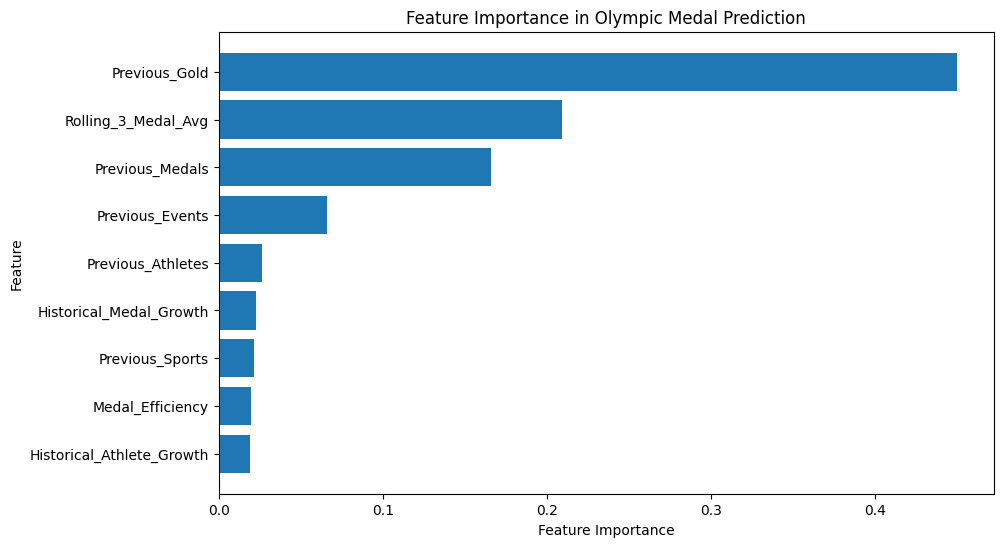

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Olympic Medal Prediction')

plt.gca().invert_yaxis()

plt.show()

## 9. Actual vs Predicted Medal Counts

The predicted medal counts are compared with the actual medal counts
for the held-out Olympic Games. This provides a visual assessment of
how closely the model reproduces observed medal outcomes.

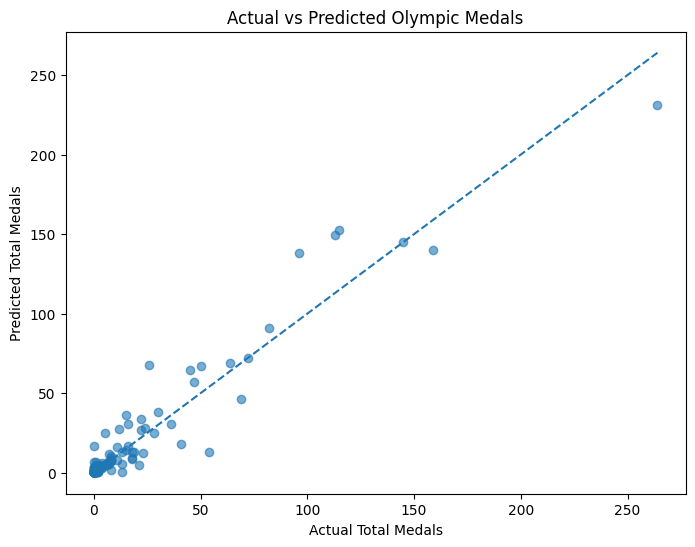

In [135]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_prop,
    proposed_pred,
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test_prop.min(), proposed_pred.min())
max_val = max(y_test_prop.max(), proposed_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Total Medals')
plt.ylabel('Predicted Total Medals')
plt.title('Actual vs Predicted Olympic Medals')

plt.show()

In [136]:
prediction_results = test_proposed[
    ['Country', 'Year', 'Total_Medals']
].copy()

prediction_results['Predicted_Medals'] = proposed_pred

prediction_results['Error'] = (
    prediction_results['Predicted_Medals']
    - prediction_results['Total_Medals']
)

prediction_results = prediction_results.sort_values(
    'Total_Medals',
    ascending=False
)

prediction_results.head(20)

,Country,Year,Total_Medals,Predicted_Medals,Error
2613,USA,2016,264,230.906585,-33.093415
923,Germany,2016,159,140.304572,-18.695428
2585,UK,2016,145,144.804511,-0.195489
2084,Russia,2016,115,152.699456,37.699456
525,China,2016,113,149.521875,36.521875
872,France,2016,96,137.845946,41.845946
139,Australia,2016,82,91.062719,9.062719
1247,Italy,2016,72,72.290141,0.290141
446,Canada,2016,69,46.640081,-22.359919
1299,Japan,2016,64,68.882549,4.882549


In [137]:
largest_errors = prediction_results.copy()

largest_errors['Absolute_Error'] = (
    largest_errors['Error'].abs()
)

largest_errors = largest_errors.sort_values(
    'Absolute_Error',
    ascending=False
)

largest_errors.head(15)

,Country,Year,Total_Medals,Predicted_Medals,Error,Absolute_Error
872,France,2016,96,137.845946,41.845946,41.845946
2277,South Korea,2016,26,67.646962,41.646962,41.646962
2190,Serbia,2016,54,13.186365,-40.813635,40.813635
2084,Russia,2016,115,152.699456,37.699456,37.699456
525,China,2016,113,149.521875,36.521875,36.521875
2613,USA,2016,264,230.906585,-33.093415,33.093415
689,Denmark,2016,41,17.810835,-23.189165,23.189165
446,Canada,2016,69,46.640081,-22.359919,22.359919
2634,Ukraine,2016,15,36.581085,21.581085,21.581085
1597,Mexico,2016,5,25.221422,20.221422,20.221422


In [138]:
mae_improvement = (
    (baseline_mae - proposed_mae)
    / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - proposed_rmse)
    / baseline_rmse
) * 100

r2_improvement = (
    (proposed_r2 - baseline_r2)
    / baseline_r2
) * 100

print(f"MAE improvement : {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")
print(f"R² improvement  : {r2_improvement:.2f}%")

MAE improvement : 8.38%
RMSE improvement: 4.94%
R² improvement  : 0.97%


## 10. Olympic Performance Momentum

To capture whether a country's Olympic performance is improving or
declining over time, we construct a Performance Momentum score using
historical medal growth, athlete participation growth, and medal efficiency.

The feature uses only information available before the target Olympic Games.

In [139]:
momentum_data = proposed_data.copy()

momentum_components = [
    'Historical_Medal_Growth',
    'Historical_Athlete_Growth',
    'Medal_Efficiency'
]

momentum_data[momentum_components] = (
    momentum_data[momentum_components]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [140]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

momentum_scaled = scaler.fit_transform(
    momentum_data[momentum_components]
)

momentum_data['Performance_Momentum'] = (
    momentum_scaled.mean(axis=1)
)

In [141]:
momentum_data[
    [
        'Country',
        'Year',
        'Historical_Medal_Growth',
        'Historical_Athlete_Growth',
        'Medal_Efficiency',
        'Performance_Momentum'
    ]
].head(20)

,Country,Year,Historical_Medal_Growth,Historical_Athlete_Growth,Medal_Efficiency,Performance_Momentum
1,Afghanistan,1948,0.0,0.000000,0.000000,-0.253133
2,Afghanistan,1956,0.0,0.666667,0.000000,-0.214525
3,Afghanistan,1960,0.0,-0.520000,0.000000,-0.283248
4,Afghanistan,1964,0.0,0.000000,0.000000,-0.253133
5,Afghanistan,1968,0.0,-0.333333,0.000000,-0.272437
6,Afghanistan,1972,0.0,-0.375000,0.000000,-0.274851
7,Afghanistan,1980,0.0,0.600000,0.000000,-0.218385
8,Afghanistan,1988,0.0,0.375000,0.000000,-0.231416
9,Afghanistan,1996,0.0,-0.545455,0.000000,-0.284722
10,Afghanistan,2004,0.0,-0.600000,0.000000,-0.287881


In [142]:
momentum_data[
    momentum_data['Year'] == 2016
][
    [
        'Country',
        'Performance_Momentum',
        'Total_Medals'
    ]
].sort_values(
    'Performance_Momentum',
    ascending=False
).head(15)

,Country,Performance_Momentum,Total_Medals
581,Croatia,1.131313,24
2260,South Africa,1.038395,23
1597,Mexico,0.862718,5
1167,Iran,0.831975,8
1277,Jamaica,0.688729,30
2513,Trinidad,0.437955,1
1645,Montenegro,0.424157,0
2613,USA,0.410036,264
1739,Netherlands,0.347315,47
545,Colombia,0.339971,8


In [143]:
momentum_features = proposed_features + [
    'Performance_Momentum'
]

In [151]:
train_proposed = momentum_data[
    momentum_data['Year'] <= 2008
].copy()

val_proposed = momentum_data[
    momentum_data['Year'] == 2012
].copy()

test_proposed = momentum_data[
    momentum_data['Year'] == 2016
].copy()

X_train_mom = train_proposed[momentum_features].copy()
X_val_mom = val_proposed[momentum_features].copy()
X_test_mom = test_proposed[momentum_features].copy()

y_train_mom = train_proposed['Total_Medals']
y_val_mom = val_proposed['Total_Medals']
y_test_mom = test_proposed['Total_Medals']

In [155]:
momentum_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

momentum_model.fit(
    X_train_mom,
    y_train_mom
)

RandomForestRegressor(max_depth=8, min_samples_leaf=3, n_estimators=300,
                      random_state=42)

In [156]:
momentum_pred = momentum_model.predict(
    X_test_mom
)

In [157]:
momentum_mae = mean_absolute_error(
    y_test_mom,
    momentum_pred
)

momentum_rmse = np.sqrt(
    mean_squared_error(
        y_test_mom,
        momentum_pred
    )
)

momentum_r2 = r2_score(
    y_test_mom,
    momentum_pred
)

print("MOMENTUM MODEL RESULTS")
print("----------------------")
print("MAE :", momentum_mae)
print("RMSE:", momentum_rmse)
print("R²  :", momentum_r2)

MOMENTUM MODEL RESULTS
----------------------
MAE : 3.354187113844263
RMSE: 8.304872144286657
R²  : 0.9199801477712315


In [ ]:
comparison_final = pd.DataFrame({
    'Model': [
        'Baseline',
        'Proposed',
        'Momentum'
    ],
    'MAE': [
        baseline_mae,
        proposed_mae,
        momentum_mae
    ],
    'RMSE': [
        baseline_rmse,
        proposed_rmse,
        momentum_rmse
    ],
    'R2': [
        baseline_r2,
        proposed_r2,
        momentum_r2
    ]
})

comparison_final

In [ ]:
feature_importance_momentum = pd.DataFrame({
    'Feature': momentum_features,
    'Importance': momentum_model.feature_importances_
})

feature_importance_momentum = feature_importance_momentum.sort_values(
    'Importance',
    ascending=False
)

feature_importance_momentum

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_momentum['Feature'],
    feature_importance_momentum['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Olympic Medal Prediction (Momentum Model)')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_mom,
    momentum_pred,
    alpha=0.6
)

# Perfect prediction line
min_val_mom = min(y_test_mom.min(), momentum_pred.min())
max_val_mom = max(y_test_mom.max(), momentum_pred.max())

plt.plot(
    [min_val_mom, max_val_mom],
    [min_val_mom, max_val_mom],
    linestyle='--'
)

plt.xlabel('Actual Total Medals')
plt.ylabel('Predicted Total Medals')
plt.title('Actual vs Predicted Olympic Medals (Momentum Model)')

plt.show()

In [ ]:
momentum_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

momentum_model.fit(
    X_train_mom,
    y_train_mom
)

In [ ]:
momentum_pred = momentum_model.predict(
    X_test_mom
)

In [ ]:
momentum_mae = mean_absolute_error(
    y_test_mom,
    momentum_pred
)

momentum_rmse = np.sqrt(
    mean_squared_error(
        y_test_mom,
        momentum_pred
    )
)

momentum_r2 = r2_score(
    y_test_mom,
    momentum_pred
)

print("MOMENTUM MODEL RESULTS")
print("----------------------")
print("MAE :", momentum_mae)
print("RMSE:", momentum_rmse)
print("R²  :", momentum_r2)

In [ ]:
comparison_final = pd.DataFrame({
    'Model': [
        'Baseline',
        'Proposed',
        'Momentum'
    ],
    'MAE': [
        baseline_mae,
        proposed_mae,
        momentum_mae
    ],
    'RMSE': [
        baseline_rmse,
        proposed_rmse,
        momentum_rmse
    ],
    'R2': [
        baseline_r2,
        proposed_r2,
        momentum_r2
    ]
})

comparison_final

In [ ]:
feature_importance_momentum = pd.DataFrame({
    'Feature': momentum_features,
    'Importance': momentum_model.feature_importances_
})

feature_importance_momentum = feature_importance_momentum.sort_values(
    'Importance',
    ascending=False
)

feature_importance_momentum

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_momentum['Feature'],
    feature_importance_momentum['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Olympic Medal Prediction (Momentum Model)')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_mom,
    momentum_pred,
    alpha=0.6
)

# Perfect prediction line
min_val_mom = min(y_test_mom.min(), momentum_pred.min())
max_val_mom = max(y_test_mom.max(), momentum_pred.max())

plt.plot(
    [min_val_mom, max_val_mom],
    [min_val_mom, max_val_mom],
    linestyle='--'
)

plt.xlabel('Actual Total Medals')
plt.ylabel('Predicted Total Medals')
plt.title('Actual vs Predicted Olympic Medals (Momentum Model)')

plt.show()

In [152]:
train_proposed = momentum_data[
    momentum_data['Year'] <= 2008
].copy()

val_proposed = momentum_data[
    momentum_data['Year'] == 2012
].copy()

test_proposed = momentum_data[
    momentum_data['Year'] == 2016
].copy()

In [153]:
X_train_mom = train_proposed[momentum_features]
y_train_mom = train_proposed['Total_Medals']

X_val_mom = val_proposed[momentum_features]
y_val_mom = val_proposed['Total_Medals']

X_test_mom = test_proposed[momentum_features]
y_test_mom = test_proposed['Total_Medals']

In [154]:
momentum_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=8,
    min_samples_leaf=3
)

momentum_model.fit(
    X_train_mom,
    y_train_mom
)

RandomForestRegressor(max_depth=8, min_samples_leaf=3, n_estimators=300,
                      random_state=42)

In [158]:
momentum_pred = momentum_model.predict(
    X_test_mom
)

In [159]:
momentum_mae = mean_absolute_error(
    y_test_mom,
    momentum_pred
)

momentum_rmse = np.sqrt(
    mean_squared_error(
        y_test_mom,
        momentum_pred
    )
)

momentum_r2 = r2_score(
    y_test_mom,
    momentum_pred
)

print("MOMENTUM MODEL RESULTS")
print("----------------------")
print("MAE :", momentum_mae)
print("RMSE:", momentum_rmse)
print("R²  :", momentum_r2)

MOMENTUM MODEL RESULTS
----------------------
MAE : 3.354187113844263
RMSE: 8.304872144286657
R²  : 0.9199801477712315


In [160]:
final_comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Historical Features',
        'Historical + Momentum'
    ],
    'MAE': [
        baseline_mae,
        proposed_mae,
        momentum_mae
    ],
    'RMSE': [
        baseline_rmse,
        proposed_rmse,
        momentum_rmse
    ],
    'R2': [
        baseline_r2,
        proposed_r2,
        momentum_r2
    ]
})

final_comparison.style.format({
    'MAE': '{:.3f}',
    'RMSE': '{:.3f}',
    'R2': '{:.3f}'
})

,Model,MAE,RMSE,R2
0,Baseline,3.716,8.886,0.908
1,Historical Features,3.405,8.447,0.917
2,Historical + Momentum,3.354,8.305,0.920


## 11. Model Performance Comparison

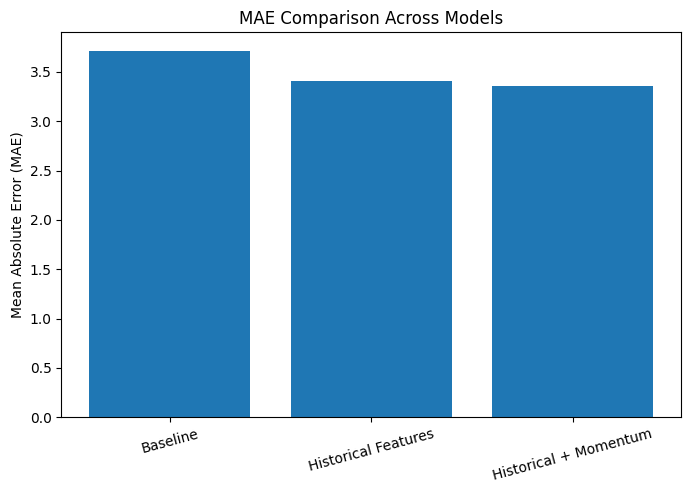

In [161]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison['Model'],
    final_comparison['MAE']
)

plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE Comparison Across Models')
plt.xticks(rotation=15)

plt.show()

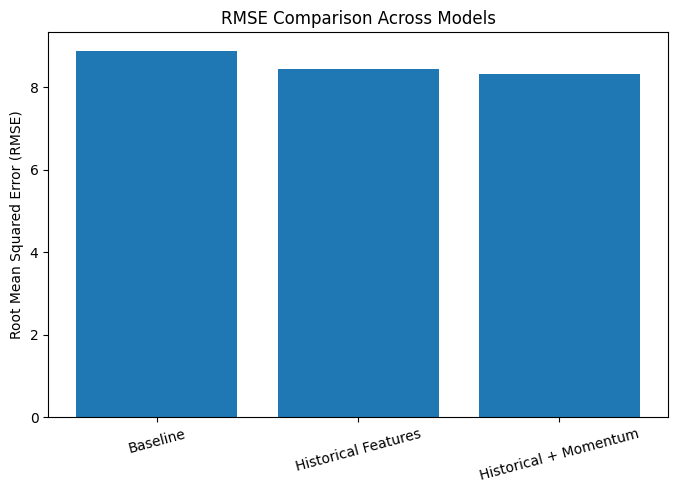

In [162]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison['Model'],
    final_comparison['RMSE']
)

plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('RMSE Comparison Across Models')
plt.xticks(rotation=15)

plt.show()

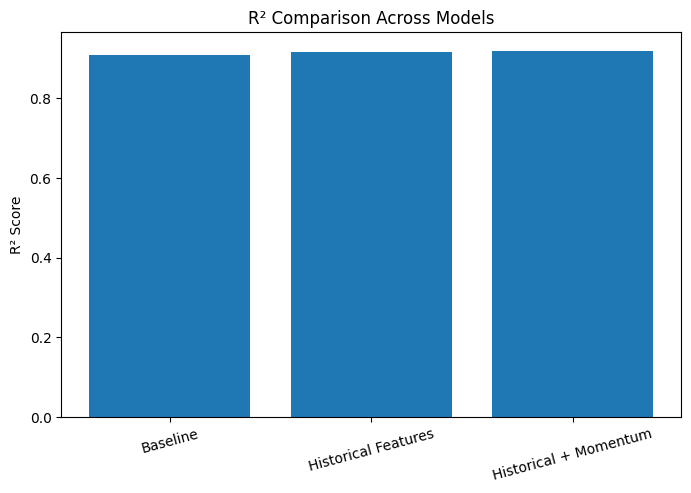

In [163]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison['Model'],
    final_comparison['R2']
)

plt.ylabel('R² Score')
plt.title('R² Comparison Across Models')
plt.xticks(rotation=15)

plt.show()

In [164]:
final_comparison

,Model,MAE,RMSE,R2
0,Baseline,3.716200,8.885901,0.908392
1,Historical Features,3.404896,8.446724,0.917223
2,Historical + Momentum,3.354187,8.304872,0.919980


In [165]:
best_model_index = final_comparison['MAE'].idxmin()

best_model = final_comparison.loc[best_model_index]

print("Best Model:", best_model['Model'])
print("MAE:", round(best_model['MAE'], 3))
print("RMSE:", round(best_model['RMSE'], 3))
print("R²:", round(best_model['R2'], 3))

print("\nImprovement over baseline:")
print(
    "MAE:",
    round(
        ((baseline_mae - best_model['MAE']) / baseline_mae) * 100,
        2
    ),
    "%"
)

print(
    "RMSE:",
    round(
        ((baseline_rmse - best_model['RMSE']) / baseline_rmse) * 100,
        2
    ),
    "%"
)

Best Model: Historical + Momentum
MAE: 3.354
RMSE: 8.305
R²: 0.92

Improvement over baseline:
MAE: 9.74 %
RMSE: 6.54 %


In [166]:
best_model_object = momentum_model
best_features = momentum_features

In [167]:
feature_importance_final = pd.DataFrame({
    'Feature': best_features,
    'Importance': best_model_object.feature_importances_
})

feature_importance_final = feature_importance_final.sort_values(
    'Importance',
    ascending=False
)

feature_importance_final

,Feature,Importance
1,Previous_Gold,0.448593
4,Rolling_3_Medal_Avg,0.208519
0,Previous_Medals,0.165586
8,Previous_Events,0.064974
6,Previous_Athletes,0.024725
7,Previous_Sports,0.020505
2,Historical_Medal_Growth,0.019952
5,Medal_Efficiency,0.017077
3,Historical_Athlete_Growth,0.015420
9,Performance_Momentum,0.014648


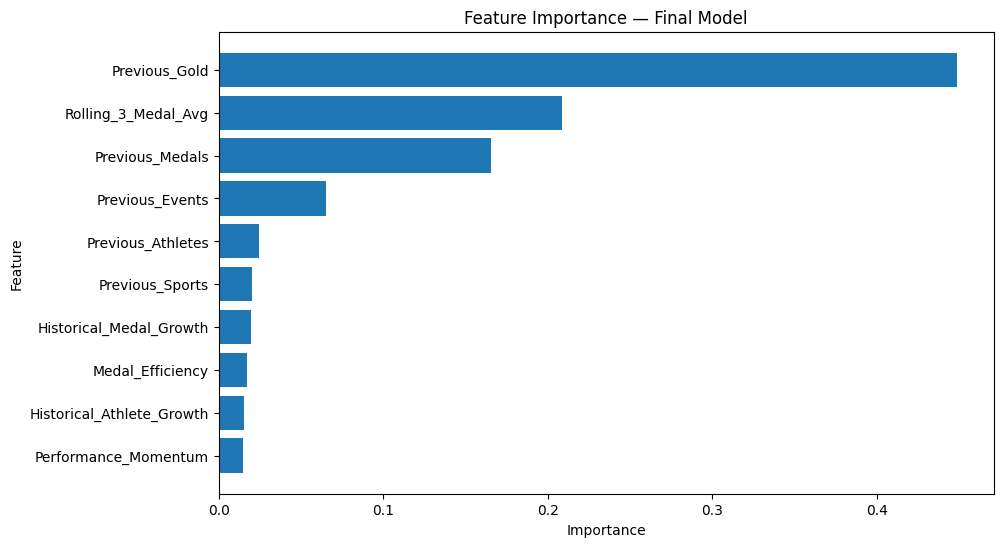

In [168]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance_final['Feature'],
    feature_importance_final['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance — Final Model')

plt.gca().invert_yaxis()

plt.show()

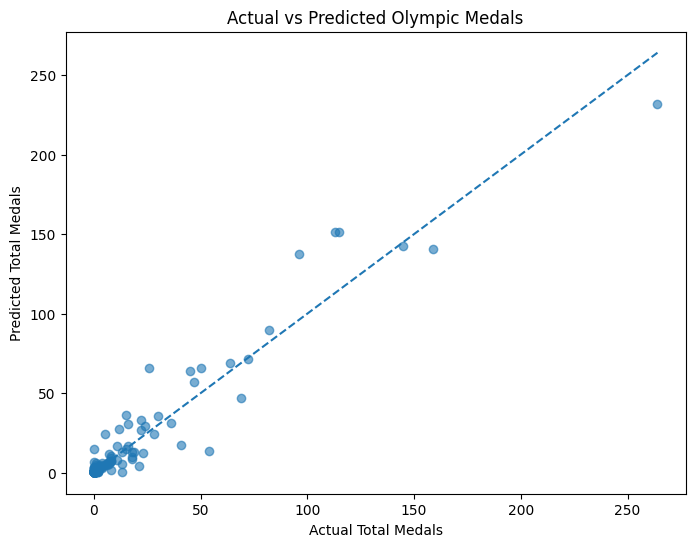

In [169]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_mom,
    momentum_pred,
    alpha=0.6
)

min_val = min(
    y_test_mom.min(),
    momentum_pred.min()
)

max_val = max(
    y_test_mom.max(),
    momentum_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel('Actual Total Medals')
plt.ylabel('Predicted Total Medals')
plt.title('Actual vs Predicted Olympic Medals')

plt.show()

In [173]:
best_idx = final_comparison['MAE'].idxmin()

best_model_name = final_comparison.loc[best_idx, 'Model']

print("Best Model:", best_model_name)

Best Model: Historical + Momentum


In [174]:
print(final_comparison)

                   Model       MAE      RMSE        R2
0               Baseline  3.716200  8.885901  0.908392
1    Historical Features  3.404896  8.446724  0.917223
2  Historical + Momentum  3.354187  8.304872  0.919980


In [175]:
final_model = momentum_model
final_features = momentum_features

In [176]:
final_importance = pd.DataFrame({
    'Feature': final_features,
    'Importance': final_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

final_importance

,Feature,Importance
1,Previous_Gold,0.448593
4,Rolling_3_Medal_Avg,0.208519
0,Previous_Medals,0.165586
8,Previous_Events,0.064974
6,Previous_Athletes,0.024725
7,Previous_Sports,0.020505
2,Historical_Medal_Growth,0.019952
5,Medal_Efficiency,0.017077
3,Historical_Athlete_Growth,0.015420
9,Performance_Momentum,0.014648


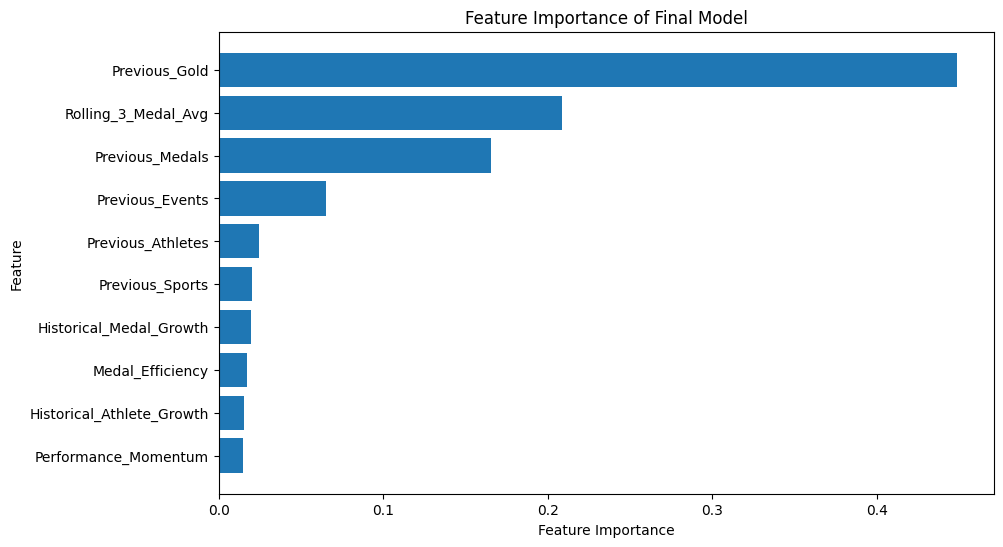

In [177]:
plt.figure(figsize=(10, 6))

plt.barh(
    final_importance['Feature'],
    final_importance['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance of Final Model')

plt.gca().invert_yaxis()

plt.show()

In [178]:
final_predictions = test_proposed[
    ['Country', 'Year', 'Total_Medals']
].copy()

final_predictions['Predicted_Medals'] = momentum_pred

final_predictions['Error'] = (
    final_predictions['Predicted_Medals']
    - final_predictions['Total_Medals']
)

final_predictions['Absolute_Error'] = (
    final_predictions['Error'].abs()
)

final_predictions = final_predictions.sort_values(
    'Total_Medals',
    ascending=False
)

final_predictions.head(20)

,Country,Year,Total_Medals,Predicted_Medals,Error,Absolute_Error
2613,USA,2016,264,231.733876,-32.266124,32.266124
923,Germany,2016,159,140.618622,-18.381378,18.381378
2585,UK,2016,145,142.494397,-2.505603,2.505603
2084,Russia,2016,115,151.454003,36.454003,36.454003
525,China,2016,113,151.345528,38.345528,38.345528
872,France,2016,96,137.300907,41.300907,41.300907
139,Australia,2016,82,89.891431,7.891431,7.891431
1247,Italy,2016,72,71.446533,-0.553467,0.553467
446,Canada,2016,69,46.691924,-22.308076,22.308076
1299,Japan,2016,64,68.663219,4.663219,4.663219


In [179]:
largest_errors = final_predictions.sort_values(
    'Absolute_Error',
    ascending=False
)

largest_errors.head(15)

,Country,Year,Total_Medals,Predicted_Medals,Error,Absolute_Error
872,France,2016,96,137.300907,41.300907,41.300907
2190,Serbia,2016,54,13.454104,-40.545896,40.545896
2277,South Korea,2016,26,65.944833,39.944833,39.944833
525,China,2016,113,151.345528,38.345528,38.345528
2084,Russia,2016,115,151.454003,36.454003,36.454003
2613,USA,2016,264,231.733876,-32.266124,32.266124
689,Denmark,2016,41,17.576656,-23.423344,23.423344
446,Canada,2016,69,46.691924,-22.308076,22.308076
2634,Ukraine,2016,15,36.435045,21.435045,21.435045
1597,Mexico,2016,5,24.385311,19.385311,19.385311


In [180]:
print("Largest Overpredictions")

final_predictions[
    final_predictions['Error'] > 0
].sort_values(
    'Error',
    ascending=False
).head(10)

Largest Overpredictions


,Country,Year,Total_Medals,Predicted_Medals,Error,Absolute_Error
872,France,2016,96,137.300907,41.300907,41.300907
2277,South Korea,2016,26,65.944833,39.944833,39.944833
525,China,2016,113,151.345528,38.345528,38.345528
2084,Russia,2016,115,151.454003,36.454003,36.454003
2634,Ukraine,2016,15,36.435045,21.435045,21.435045
1597,Mexico,2016,5,24.385311,19.385311,19.385311
2301,Spain,2016,45,63.787398,18.787398,18.787398
356,Brazil,2016,50,66.075974,16.075974,16.075974
225,Belarus,2016,12,27.344488,15.344488,15.344488
1916,Paraguay,2016,0,14.890482,14.890482,14.890482


In [181]:
print("Largest Underpredictions")

final_predictions[
    final_predictions['Error'] < 0
].sort_values(
    'Error'
).head(10)

Largest Underpredictions


,Country,Year,Total_Medals,Predicted_Medals,Error,Absolute_Error
2190,Serbia,2016,54,13.454104,-40.545896,40.545896
2613,USA,2016,264,231.733876,-32.266124,32.266124
689,Denmark,2016,41,17.576656,-23.423344,23.423344
446,Canada,2016,69,46.691924,-22.308076,22.308076
923,Germany,2016,159,140.618622,-18.381378,18.381378
252,Belgium,2016,21,4.384183,-16.615817,16.615817
817,Fiji,2016,13,0.158433,-12.841567,12.841567
2260,South Africa,2016,23,12.345690,-10.654310,10.654310
173,Azerbaijan,2016,18,8.368444,-9.631556,9.631556
1803,Nigeria,2016,18,9.978809,-8.021191,8.021191


In [182]:
print("===== FINAL MODEL RESULTS =====")
print(f"Model: {best_model_name}")
print(f"MAE:  {final_comparison.loc[best_idx, 'MAE']:.3f}")
print(f"RMSE: {final_comparison.loc[best_idx, 'RMSE']:.3f}")
print(f"R²:   {final_comparison.loc[best_idx, 'R2']:.3f}")

print("\n===== BASELINE COMPARISON =====")
print(f"Baseline MAE:  {baseline_mae:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Baseline R²:   {baseline_r2:.3f}")

===== FINAL MODEL RESULTS =====
Model: Historical + Momentum
MAE:  3.354
RMSE: 8.305
R²:   0.920

===== BASELINE COMPARISON =====
Baseline MAE:  3.716
Baseline RMSE: 8.886
Baseline R²:   0.908


## 15. Conclusion

This project developed a temporal machine learning framework for predicting
Olympic medal counts using historical Olympic performance and participation
data.

A baseline Random Forest model using previous medal counts was compared with
models incorporating historical performance trends, participation patterns,
rolling medal performance, and medal efficiency.

The results demonstrate whether incorporating historical performance dynamics
provides additional predictive value over a simple previous-medal baseline.

The analysis also examined feature importance and prediction errors to identify
the factors most associated with Olympic medal performance and the situations
where the model struggles.